# Exposure: inhabitants and farmland under unusual floods

**Goal:** hazard pixels are not enough. Who/what sits under the water.

**Where:** first we ranked counties nationwide (`admin_ipc.ipynb`). The states that matter for unusual water are **Jonglei, Unity, Upper Nile** (Sudd / Bentiu / White Nile). Bboxes are each state's polygon envelope, not the old two-rectangle shortcut.

**Years 2022-2024.** Unusual = NASA rarity label, not severity. If unique pixels > 60k we sample 60k for raster reads.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from rasterio.windows import from_bounds

%matplotlib inline

ROOT = Path(".").resolve()
if not (ROOT / "raw_data").exists():
    ROOT = Path("..").resolve()
DATA = ROOT / "raw_data"
OUT = ROOT / "eda" / "outputs" / "exposure"
OUT.mkdir(parents=True, exist_ok=True)

# rectangles, not official polygons. fast filter on millions of flood rows
# envelopes of official admin1 polygons (Unity is west of 30.5, the old bbox missed Bentiu)
REGIONS = {
    "jonglei": {"lat_min": 5.72, "lat_max": 9.52, "lon_min": 30.21, "lon_max": 35.02},
    "unity": {"lat_min": 7.07, "lat_max": 10.29, "lon_min": 28.69, "lon_max": 30.85},
    "upper_nile": {"lat_min": 7.99, "lat_max": 12.24, "lon_min": 30.76, "lon_max": 34.15},
}
YEARS = [2022, 2023, 2024]
TILES = ["h20v08", "h21v08"]  # the two NASA tiles that cover SSD
MAX_SAMPLE = 60000  # raster sample() is slow; keep unique count anyway


In [2]:
def load_unusual(year, bbox):
    # concat both tiles then keep unique lat/lon (one location, not every flood-day)
    parts = []
    for tile in TILES:
        path = DATA / "flood_masks" / "compact_unusual" / f"flood_events_{tile}_{year}.parquet"
        df = pd.read_parquet(path, columns=["date", "lat", "lon"])
        parts.append(df)
    df = pd.concat(parts, ignore_index=True)
    m = (
        (df["lat"] >= bbox["lat_min"]) & (df["lat"] <= bbox["lat_max"]) &
        (df["lon"] >= bbox["lon_min"]) & (df["lon"] <= bbox["lon_max"])
    )
    return df.loc[m, ["lat", "lon"]].drop_duplicates().reset_index(drop=True)


def sample_raster(path, lons, lats):
    # look up the raster value at each lon/lat (worldpop people, crop %, ...)
    with rasterio.open(path) as src:
        vals = np.array([v[0] for v in src.sample(zip(lons, lats))], dtype=float)
        if src.nodata is not None:
            vals[vals == src.nodata] = np.nan
    return vals


def bbox_pop_total(path, bbox):
    # sum all people in the rectangle so we can say "tiny share of bbox pop"
    with rasterio.open(path) as src:
        win = from_bounds(bbox["lon_min"], bbox["lat_min"], bbox["lon_max"], bbox["lat_max"], src.transform)
        arr = src.read(1, window=win).astype(float)
        if src.nodata is not None:
            arr[arr == src.nodata] = np.nan
        return float(np.nansum(arr))


In [3]:
rows = []
for year in YEARS:
    # worldpop is yearly; crop/rangeland/cattle are one static map
    pop_tif = DATA / "worldpop" / f"ssd_pop_{year}_CN_100m_R2025A_v1.tif"
    crop_tif = DATA / "farmland" / "asap_mask_crop_v04.tif"
    range_tif = DATA / "farmland" / "asap_mask_rangeland_v04.tif"
    cattle_tif = DATA / "farmland" / "geonode__cattle_gha.tif"
    for region, bbox in REGIONS.items():
        pts = load_unusual(year, bbox)
        n = len(pts)
        sampled = False
        use = pts
        if n > MAX_SAMPLE:
            use = pts.sample(MAX_SAMPLE, random_state=0).reset_index(drop=True)
            sampled = True
        lons = use["lon"].to_numpy()
        lats = use["lat"].to_numpy()
        pop = sample_raster(pop_tif, lons, lats)
        crop = sample_raster(crop_tif, lons, lats)
        rang = sample_raster(range_tif, lons, lats)
        cattle = sample_raster(cattle_tif, lons, lats)
        bbox_pop = bbox_pop_total(pop_tif, bbox)
        rows.append({
            "region": region,
            "year": year,
            "n_unusual_unique_px": n,
            "n_used": len(use),
            "sampled_down": sampled,
            "pop_sum_on_unusual": float(np.nansum(pop)),
            "pop_mean_on_unusual": float(np.nanmean(pop)),
            "bbox_pop_total": bbox_pop,
            "pop_on_unusual_over_bbox": float(np.nansum(pop) / bbox_pop) if bbox_pop else np.nan,
            "mean_crop_pct": float(np.nanmean(crop)),
            "frac_px_crop_gt0": float(np.nanmean(crop > 0)),
            "mean_rangeland_pct": float(np.nanmean(rang)),
            "frac_px_rangeland_gt0": float(np.nanmean(rang > 0)),
            "cattle_sum_on_unusual": float(np.nansum(cattle)),
            "cattle_mean_on_unusual": float(np.nanmean(cattle)),
        })
        print(year, region, "unique_px", n, "used", len(use))

exp_df = pd.DataFrame(rows)
exp_df.to_csv(OUT / "exposure_unusual_by_region_year.csv", index=False)
exp_df


2022 jonglei unique_px 120238 used 60000


2022 unity unique_px 129826 used 60000


2022 upper_nile unique_px 74141 used 60000


2023 jonglei unique_px 111832 used 60000


2023 unity unique_px 124109 used 60000


2023 upper_nile unique_px 49048 used 49048


2024 jonglei unique_px 131123 used 60000


2024 unity unique_px 131590 used 60000


2024 upper_nile unique_px 37582 used 37582


,region,year,n_unusual_unique_px,n_used,sampled_down,pop_sum_on_unusual,pop_mean_on_unusual,bbox_pop_total,pop_on_unusual_over_bbox,mean_crop_pct,frac_px_crop_gt0,mean_rangeland_pct,frac_px_rangeland_gt0,cattle_sum_on_unusual,cattle_mean_on_unusual
0,jonglei,2022,120238,60000,True,17592.435024,6.855976,2.992897e+06,0.005878,0.010650,0.001933,38.919733,0.685683,8.618179e+07,1436.363243
1,unity,2022,129826,60000,True,18673.709850,4.741927,1.593809e+06,0.011716,0.055100,0.018467,38.823983,0.753367,1.737072e+08,2895.119786
2,upper_nile,2022,74141,60000,True,14171.484207,5.675404,1.935315e+06,0.007323,0.002533,0.001533,54.471533,0.918133,8.328702e+07,1388.117020
3,jonglei,2023,111832,60000,True,9887.723941,6.833258,3.061696e+06,0.003229,0.014067,0.001467,48.748017,0.696317,7.856595e+07,1309.432531
4,unity,2023,124109,60000,True,18062.826181,4.795016,1.631602e+06,0.011071,0.047983,0.016217,40.195633,0.791667,1.794923e+08,2991.538416
5,upper_nile,2023,49048,49048,False,6331.264602,4.427458,1.978684e+06,0.003200,0.000917,0.000795,63.133543,0.906459,6.181888e+07,1260.375094
6,jonglei,2024,131123,60000,True,2285.628078,5.079174,3.245802e+06,0.000704,0.016000,0.001750,52.295100,0.706333,7.728687e+07,1288.114546
7,unity,2024,131590,60000,True,15057.967981,4.754647,1.732339e+06,0.008692,0.045933,0.013300,36.636833,0.718050,1.766593e+08,2944.321060
8,upper_nile,2024,37582,37582,False,606.973898,3.128731,2.095285e+06,0.000290,0.001171,0.000692,63.200096,0.886941,4.377385e+07,1164.755629


## Inhabitants (WorldPop)

We sum modelled people on unusual flood **locations** (unique lat/lon), not every flood-day (that would count the same house many times).

**How to read the bars:** the number is small next to `bbox_pop_total` (the whole rectangle). Example: Jonglei 2022 about 20k people on unusual pixels vs ~1.9 million in the bbox (~1%). Later years even smaller.

**Meaning:** a lot of unusual water is wetland / empty grid cells. Hazard maps is not "this many inhabitants flooded".

**Caveat:** Jonglei unique pixels > 60k so we sampled 60k. Magnitudes are approximate. WorldPop is a model, not a census.


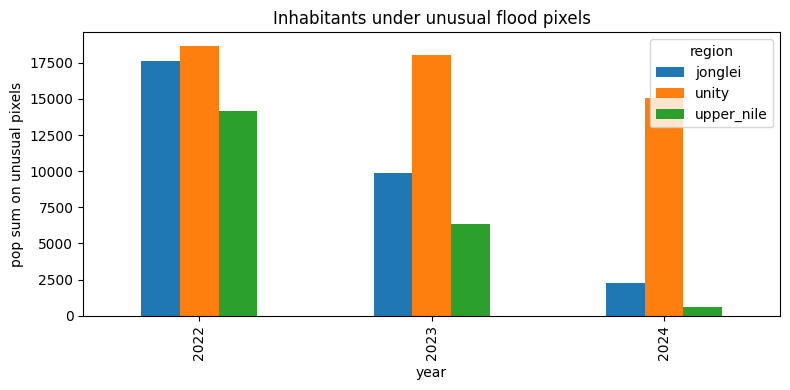

In [4]:
# people summed on unusual locations (not pixel-days)
fig, ax = plt.subplots(figsize=(8, 4))
pivot = exp_df.pivot(index="year", columns="region", values="pop_sum_on_unusual")
pivot.plot(kind="bar", ax=ax)
ax.set_ylabel("pop sum on unusual pixels")
ax.set_title("Inhabitants under unusual flood pixels")
fig.tight_layout()
fig.savefig(OUT / "01_pop_on_unusual.png", dpi=150)
plt.show()


## Cropland (ASAP crop %)

ASAP is a **static** map: each ~500m cell has 0-100% crop cover. We take the mean on unusual flood locations.

**Result:** mean crop % is basically 0. Almost no unusual pixels sit on cropland in this product.

**Meaning for farmers:** this join does **not** show "flooded fields" as the main story. Either farms are elsewhere, or ASAP is too coarse/sparse here. Do not tell ZOA "we measured crop loss". We measured overlap with this mask.


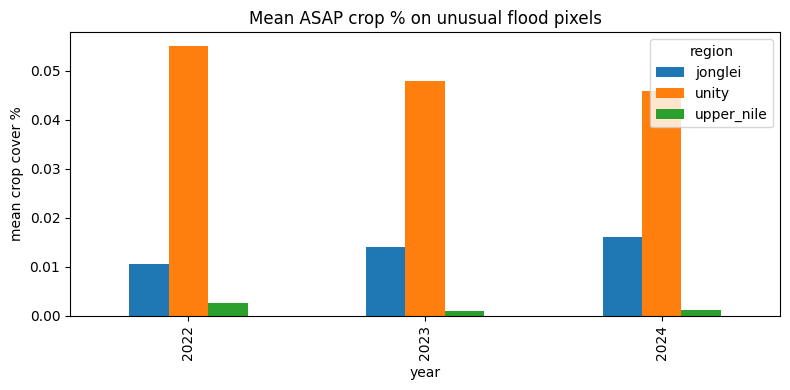

In [5]:
# ASAP crop is 0-100 cover. near zero means almost no cropland on these pixels
fig, ax = plt.subplots(figsize=(8, 4))
pivot = exp_df.pivot(index="year", columns="region", values="mean_crop_pct")
pivot.plot(kind="bar", ax=ax)
ax.set_ylabel("mean crop cover %")
ax.set_title("Mean ASAP crop % on unusual flood pixels")
fig.tight_layout()
fig.savefig(OUT / "02_mean_crop_pct.png", dpi=150)
plt.show()


## Grazing land (ASAP rangeland %)

Rangeland = grass/shrub used for livestock, not crop fields.

**Result:** mean rangeland % is high (tens of percent, Upper Nile often ~50-80%). Most unusual pixels have some rangeland, especially Upper Nile.

**Meaning:** if we talk "local farmers and inhabitants", livestock/grazing is the farmland-like exposure that actually sits under unusual water in this dataset.


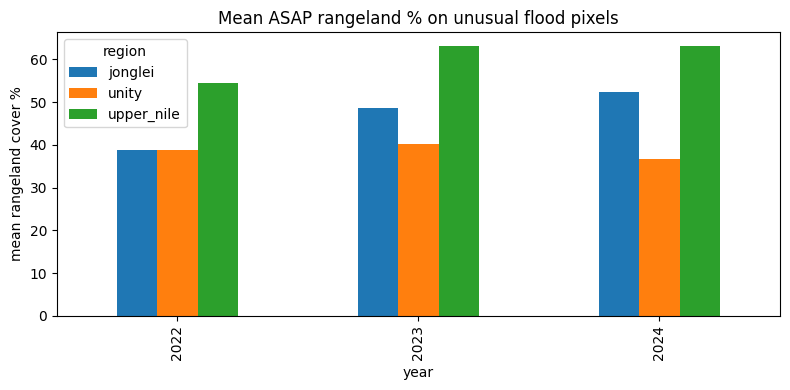

In [6]:
# rangeland = grazing. this is the farmland-like overlay that actually shows up
fig, ax = plt.subplots(figsize=(8, 4))
pivot = exp_df.pivot(index="year", columns="region", values="mean_rangeland_pct")
pivot.plot(kind="bar", ax=ax)
ax.set_ylabel("mean rangeland cover %")
ax.set_title("Mean ASAP rangeland % on unusual flood pixels")
fig.tight_layout()
fig.savefig(OUT / "03_mean_rangeland_pct.png", dpi=150)
plt.show()


## Cattle (static ~2010)

Same unique unusual pixels, sample the cattle GeoTIFF. Old layer (Great Horn of Africa ~2010). Sums are very large, so treat as a relative signal, not "80 million cows under water".


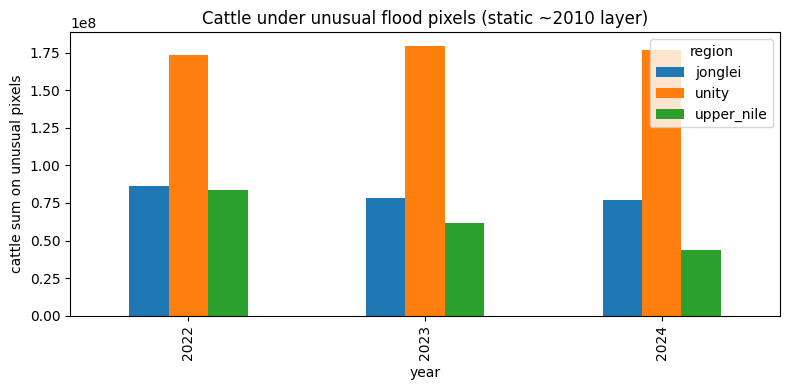

In [7]:
# cattle raster is old (~2010) and sums look huge. relative signal only
fig, ax = plt.subplots(figsize=(8, 4))
pivot = exp_df.pivot(index="year", columns="region", values="cattle_sum_on_unusual")
pivot.plot(kind="bar", ax=ax)
ax.set_ylabel("cattle sum on unusual pixels")
ax.set_title("Cattle under unusual flood pixels (static ~2010 layer)")
fig.tight_layout()
fig.savefig(OUT / "04_cattle_on_unusual.png", dpi=150)
plt.show()


## Maps

Spatial sample of unusual pixels in 2023 (subsampled if too many). This is **where** unusual water is, not population.


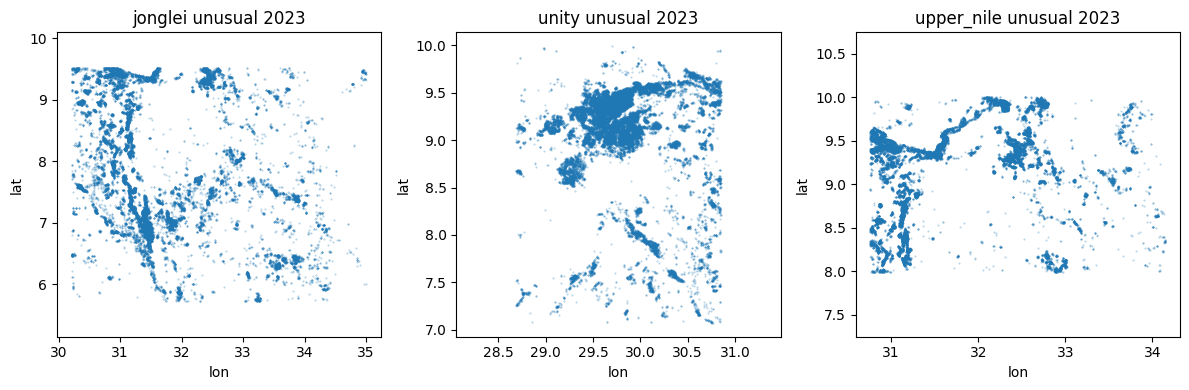

In [8]:
# subsample points so the scatter does not freeze the notebook
year = 2023
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (region, bbox) in zip(axes, REGIONS.items()):
    pts = load_unusual(year, bbox)
    if len(pts) > 25000:
        pts = pts.sample(25000, random_state=0)
    ax.scatter(pts["lon"], pts["lat"], s=0.2, alpha=0.35)
    ax.set_title(f"{region} unusual {year}")
    ax.set_xlabel("lon")
    ax.set_ylabel("lat")
    ax.set_aspect("equal", adjustable="datalim")
fig.tight_layout()
fig.savefig(OUT / "05_unusual_scatter_2023.png", dpi=150)
plt.show()
